<a href="https://colab.research.google.com/github/RayCharles8/ML-Project/blob/main/CGNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive and import all libraries
import os
import sys
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

!pip install torch-geometric torch-cluster pymatgen

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader, Batch
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set, MessagePassing
from torch_geometric.explain import GNNExplainer
from torch_cluster import radius_graph
from torch_geometric.utils import scatter
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure, Element
from torch.utils.data import Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt
import seaborn as sns

!pip install pysr
from pysr import PySRRegressor

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
BASE_DIR = "/content/drive/MyDrive/IML Project"

DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
CIF_DIR = os.path.join(BASE_DIR)

GRAPH_DIR = os.path.join(BASE_DIR, "graphs")
os.makedirs(GRAPH_DIR, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1

/usr/local/lib/python3.12/dist-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

# Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-573069,Ba2CaTl2(CuO4)2,I4/mmm,139,30,0.0000,3.950204,3.950204,30.646282,90.0,90.000000,90.0,27.733333,2.489333,Trivial,0,cifs/mp-573069.cif
1,mp-1193609,PH8IN4,P4/nbm,125,28,1.1111,7.704433,7.704433,7.932095,90.0,90.000000,90.0,7.428571,2.472143,TI,1,cifs/mp-1193609.cif
2,mp-21420,Nd(MnGe)2,I4/mmm,139,10,0.0000,4.173254,4.173254,11.115354,90.0,90.000000,90.0,34.800000,1.652000,TI,1,cifs/mp-21420.cif
3,mp-4920,Nd(GeRh)2,I4/mmm,139,10,0.0000,4.157947,4.157947,10.458460,90.0,90.000000,90.0,42.800000,1.944000,TI,1,cifs/mp-4920.cif
4,mp-15827,Ho2Ge2Os,C2/m,12,20,0.0000,10.699596,4.275589,10.037210,90.0,118.097977,90.0,54.800000,1.736000,TI,1,cifs/mp-15827.cif


In [3]:
print("Total samples:", len(df))

Total samples: 9668


In [4]:
#Check class balance
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64


In [5]:
# Build absolute CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(CIF_DIR, x))

# Quick check
print(df[['cif', 'cif_path']].head())

                   cif                                           cif_path
0   cifs/mp-573069.cif  /content/drive/MyDrive/IML Project/cifs/mp-573...
1  cifs/mp-1193609.cif  /content/drive/MyDrive/IML Project/cifs/mp-119...
2    cifs/mp-21420.cif  /content/drive/MyDrive/IML Project/cifs/mp-214...
3     cifs/mp-4920.cif  /content/drive/MyDrive/IML Project/cifs/mp-492...
4    cifs/mp-15827.cif  /content/drive/MyDrive/IML Project/cifs/mp-158...


In [6]:
os.path.exists(df['cif_path'].iloc[0])

True

# Data Splitting

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6767 | Val: 1450 | Test: 1451


# Feature Extraction

In [8]:
# Node features
def get_atom_features(element):
    el = Element(element)

    return [
        el.Z,
        el.X if el.X else 0,
        el.atomic_radius if el.atomic_radius else 0,
        el.group if el.group else 0,
        el.row if el.row else 0
    ]

# Global Features
def extract_global_features(row, structure):
    return [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

# Train Features for Scaling

In [9]:
# COLLECT TRAIN FEATURES
node_samples = []
edge_samples = []
global_samples = []

cutoff = 6.0

for _, row in train_df.iterrows():
    try:
        structure = Structure.from_file(row['cif_path'])

        # Node features
        for site in structure:
            node_samples.append(get_atom_features(site.specie.symbol))

        # Edge features (distance)
        for i, site in enumerate(structure):
            neighbors = structure.get_neighbors(site, cutoff)
            for n in neighbors:
                edge_samples.append([n.nn_distance])

        # Global features
        global_samples.append(extract_global_features(row, structure))

    except Exception as e:
        print(f"Error processing {row['cif_path']} | {e}")

# Convert safely
node_samples = np.array(node_samples)
edge_samples = np.array(edge_samples)
global_samples = np.array(global_samples)

print("Node shape:", node_samples.shape)
print("Edge shape:", edge_samples.shape)
print("Global shape:", global_samples.shape)

Node shape: (211448, 5)
Edge shape: (11843614, 1)
Global shape: (6767, 14)


In [10]:
# SCALING
node_scaler = StandardScaler().fit(node_samples)
edge_scaler = StandardScaler().fit(edge_samples)
global_scaler = StandardScaler().fit(global_samples)

# Gaussian Expansion

In [11]:
# GAUSSIAN EXPANSION

class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.2):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-(distances[..., np.newaxis] - self.filter)**2 / self.var**2)

gaussian_expansion = GaussianDistance()

# Building Graphs

In [12]:
def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # NODE FEATURES
    node_feat = [get_atom_features(site.specie.symbol) for site in structure]
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # POSITIONS
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # EDGES
    edge_index = []
    edge_attr = []
    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)
        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append([dist])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = edge_scaler.transform(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr.squeeze())
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # GLOBAL FEATURES
    global_feat = extract_global_features(row, structure)
    global_feat = global_scaler.transform([global_feat])
    u = torch.tensor(global_feat, dtype=torch.float)

    # LABEL
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        pos=pos
    )

    data.u = u
    return data

In [13]:
def build_and_save(df_split, split_name):
    print(f"Building {split_name} graphs")

    save_dir = os.path.join(GRAPH_DIR, split_name)
    os.makedirs(save_dir, exist_ok=True)

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        graph_path = os.path.join(save_dir, f"{row['mp_material_id']}.pt")

        if os.path.exists(graph_path):
            continue

        try:
            graph = build_graph(row)
            torch.save(graph, graph_path)
        except Exception as e:
            print(f"Error: {row['mp_material_id']} | {e}")


# BUILD GRAPHS PER SPLIT
build_and_save(train_df, "Train")
build_and_save(val_df, "Val")
build_and_save(test_df, "Test")

Building Train graphs


100%|██████████| 6767/6767 [00:28<00:00, 235.23it/s] 


Building Val graphs


100%|██████████| 1450/1450 [00:05<00:00, 251.14it/s]


Building Test graphs


100%|██████████| 1451/1451 [00:06<00:00, 225.90it/s]


# CharlesCGCNN Model

In [14]:
class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=128, dropout=0.2):
        super(CharlesCGCNN, self).__init__()

        # Embeddings
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # CGCNN Layers
        self.conv1 = CGConv(hidden_dim, dim=edge_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_dim)
        self.conv3 = CGConv(hidden_dim, dim=edge_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u  # global features

        # Embedding
        x = self.node_emb(x)
        u = self.global_emb(u)

        # CGCNN Layers (with gating)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv3(x, edge_index, edge_attr))

        # Pooling
        x = global_mean_pool(x, batch)

        # Combine with global features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        return out

In [15]:
# Initialize model
model = CharlesCGCNN(
    node_dim=5,
    edge_dim=31,
    global_dim=14
).to(device)

In [16]:
# Training Configuration
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [17]:
# Graph Dataset Loader
import torch
import torch.serialization
from torch_geometric.data.data import Data, DataEdgeAttr

# allow PyG objects
torch.serialization.add_safe_globals([Data, DataEdgeAttr])


class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        super().__init__()
        self.graph_dir = graph_dir

        self.files = sorted([
            f for f in os.listdir(graph_dir)
            if f.endswith(".pt")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])

        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        return data

In [18]:
train_dataset = CrystalDataset(os.path.join(GRAPH_DIR, "Train"))
val_dataset   = CrystalDataset(os.path.join(GRAPH_DIR, "Val"))
test_dataset  = CrystalDataset(os.path.join(GRAPH_DIR, "Test"))

In [19]:
# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [20]:
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 6767 | Val: 1450 | Test: 1451


# Training Loop

In [21]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Tracking
train_losses = []
val_losses = []
val_f1_scores = []
val_roc_scores = []

In [22]:
# training function
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)

        # Ensure correct shape
        y = data.y.float().view(-1, 1)

        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [23]:
# validation function
def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)

            y = data.y.float().view(-1, 1)
            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels.append(y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc

In [24]:
# training loop
best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):

    train_loss = train_epoch(train_loader)
    val_loss, val_f1, val_roc = eval_epoch(val_loader)

    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    val_roc_scores.append(val_roc)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train: 24.8602 | Val: 0.5042 | F1: 0.7543 | ROC: 0.8359
Epoch 002 | Train: 0.5275 | Val: 0.4997 | F1: 0.7926 | ROC: 0.8546
Epoch 003 | Train: 0.4941 | Val: 0.4762 | F1: 0.7841 | ROC: 0.8583
Epoch 004 | Train: 0.4763 | Val: 0.4677 | F1: 0.7953 | ROC: 0.8642
Epoch 005 | Train: 0.4636 | Val: 0.4675 | F1: 0.7936 | ROC: 0.8649
Epoch 006 | Train: 0.4615 | Val: 0.4645 | F1: 0.7885 | ROC: 0.8655
Epoch 007 | Train: 0.4476 | Val: 0.4513 | F1: 0.7949 | ROC: 0.8715
Epoch 008 | Train: 0.4387 | Val: 0.4359 | F1: 0.8068 | ROC: 0.8789
Epoch 009 | Train: 0.4300 | Val: 0.4282 | F1: 0.8080 | ROC: 0.8821
Epoch 010 | Train: 0.4245 | Val: 0.4280 | F1: 0.8061 | ROC: 0.8829
Epoch 011 | Train: 0.4202 | Val: 0.4238 | F1: 0.8081 | ROC: 0.8843
Epoch 012 | Train: 0.4177 | Val: 0.4271 | F1: 0.8133 | ROC: 0.8872
Epoch 013 | Train: 0.4168 | Val: 0.4235 | F1: 0.8095 | ROC: 0.8892
Epoch 014 | Train: 0.4127 | Val: 0.4127 | F1: 0.8111 | ROC: 0.8925
Epoch 015 | Train: 0.4059 | Val: 0.4109 | F1: 0.8190 | ROC: 0

In [25]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

# Evaluation

In [26]:
def evaluate_model(loader, name="Test"):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary

In [27]:
# load best model
model.load_state_dict(torch.load("best_model.pt"))
labels, probs, binary = evaluate_model(test_loader)


Test Performance:
Accuracy : 0.8560
F1-score : 0.8430
ROC-AUC  : 0.9193
              precision    recall  f1-score   support

         0.0       0.86      0.87      0.87       780
         1.0       0.85      0.84      0.84       671

    accuracy                           0.86      1451
   macro avg       0.86      0.85      0.85      1451
weighted avg       0.86      0.86      0.86      1451



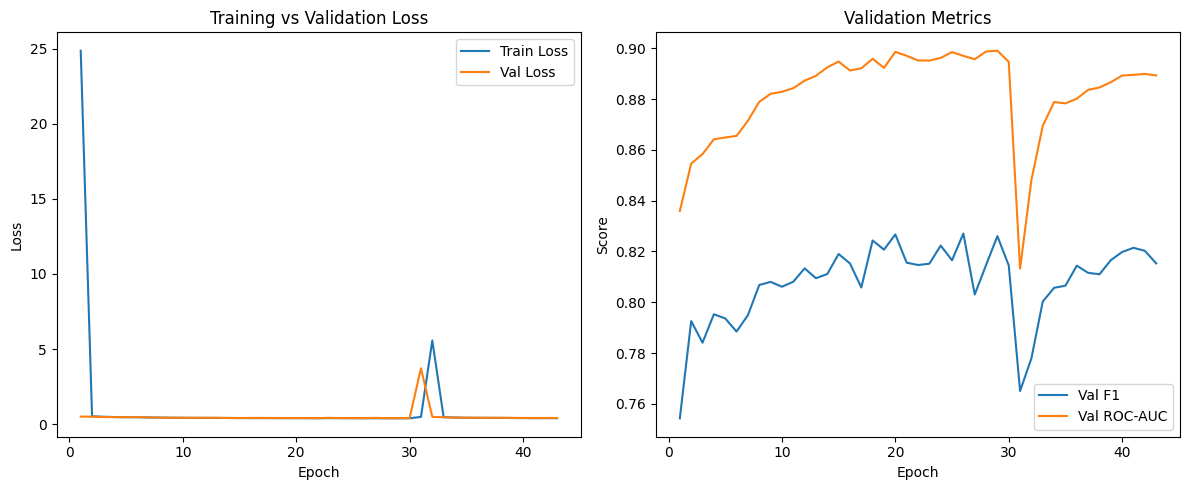

In [28]:
# training curves and validation metrics
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# LOSS
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# METRICS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_scores, label="Val F1")
plt.plot(epochs_range, val_roc_scores, label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

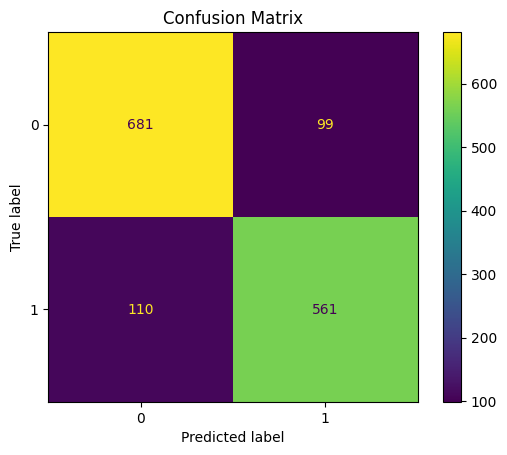

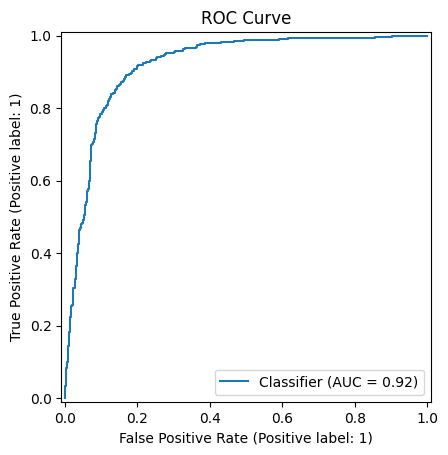

In [29]:
# confunsion matrix
cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(labels, probs)
plt.title("ROC Curve")
plt.show()

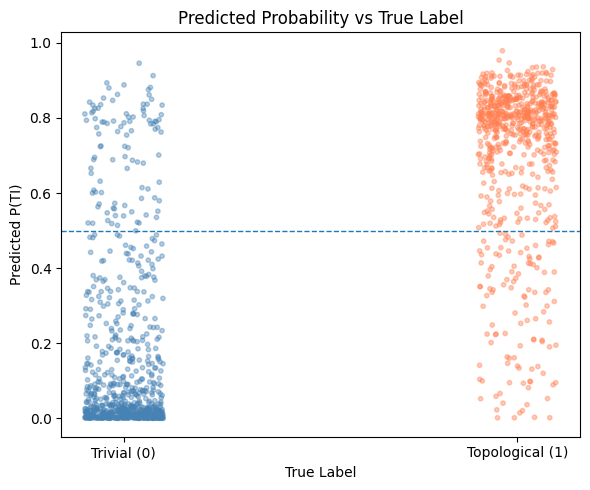

In [30]:
# scatter plot
plt.figure(figsize=(6, 5))

jitter = np.random.uniform(-0.1, 0.1, size=len(labels))

colors = ['steelblue' if l == 0 else 'coral' for l in labels]

plt.scatter(labels + jitter, probs, c=colors, alpha=0.4, s=10)

plt.axhline(0.5, linestyle='--', linewidth=1)

plt.xticks([0, 1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel('True Label')
plt.ylabel('Predicted P(TI)')
plt.title('Predicted Probability vs True Label')

plt.tight_layout()
plt.show()

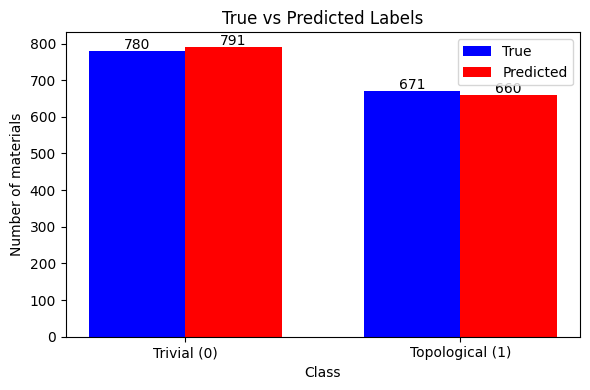

In [31]:
categories = ['Trivial (0)', 'Topological (1)']

true_counts = [(labels == 0).sum(), (labels == 1).sum()]
pred_counts = [(binary == 0).sum(), (binary == 1).sum()]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(6, 4))

bars1 = plt.bar(x - width/2, true_counts, width, label='True', color='blue')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Predicted', color='red')

for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center')

plt.xticks(x, categories)
plt.xlabel('Class')
plt.ylabel('Number of materials')
plt.title('True vs Predicted Labels')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# Regresssion scatter plot


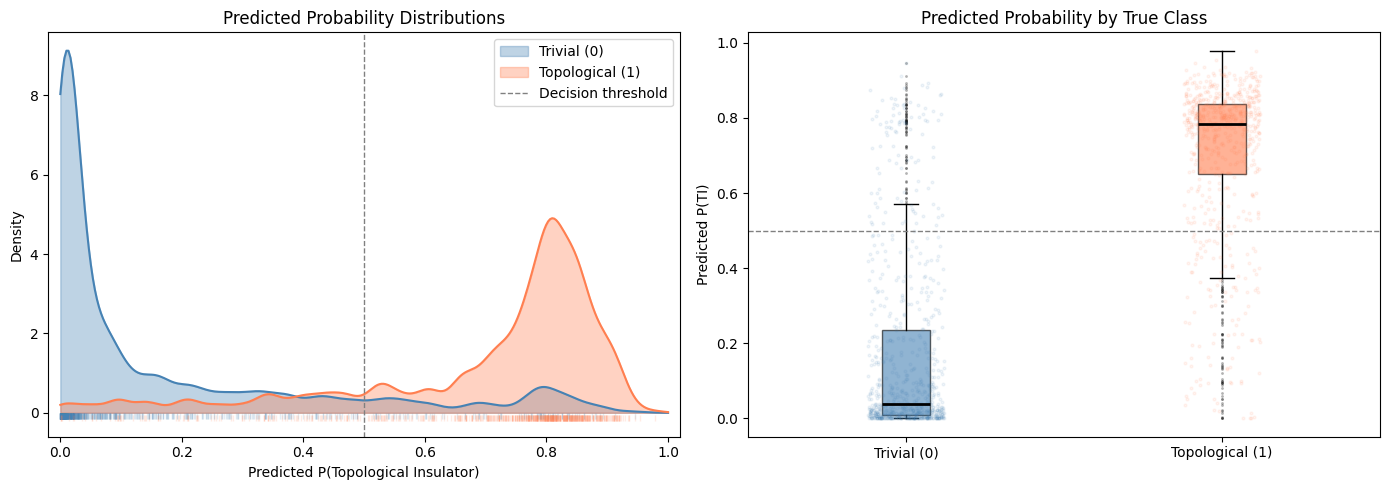


Separation: Trivial mean=0.168 | TI mean=0.700


In [32]:
# POLISHED PROBABILITY DISTRIBUTION PLOT
# (replaces your basic scatter — shows how well the model separates the two classes)

from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trivial_probs = probs[labels == 0]
topo_probs    = probs[labels == 1]

# --- LEFT: KDE + rug plot ---
ax = axes[0]
x_range = np.linspace(0, 1, 300)

kde_trivial = gaussian_kde(trivial_probs, bw_method=0.08)
kde_topo    = gaussian_kde(topo_probs,    bw_method=0.08)

ax.fill_between(x_range, kde_trivial(x_range), alpha=0.35, color='steelblue', label='Trivial (0)')
ax.plot(x_range, kde_trivial(x_range), color='steelblue', linewidth=1.5)

ax.fill_between(x_range, kde_topo(x_range), alpha=0.35, color='coral', label='Topological (1)')
ax.plot(x_range, kde_topo(x_range), color='coral', linewidth=1.5)

# Rug marks at bottom
ax.plot(trivial_probs, np.full_like(trivial_probs, -0.08),
        '|', color='steelblue', alpha=0.15, markersize=4)
ax.plot(topo_probs, np.full_like(topo_probs, -0.14),
        '|', color='coral', alpha=0.15, markersize=4)

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision threshold')
ax.set_xlabel('Predicted P(Topological Insulator)')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distributions')
ax.legend()
ax.set_xlim(-0.02, 1.02)

# --- RIGHT: Box plot per class ---
ax2 = axes[1]
bp = ax2.boxplot(
    [trivial_probs, topo_probs],
    labels=['Trivial (0)', 'Topological (1)'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('coral')
bp['boxes'][1].set_alpha(0.6)

# Strip plot overlay (jittered points)
rng = np.random.default_rng(42)
for i, (vals, col) in enumerate(zip([trivial_probs, topo_probs], ['steelblue', 'coral']), start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax2.scatter(np.full_like(vals, i) + jitter, vals,
                alpha=0.08, s=4, color=col, zorder=2)

ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Predicted P(TI)')
ax2.set_title('Predicted Probability by True Class')

plt.tight_layout()
plt.savefig('probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSeparation: Trivial mean={trivial_probs.mean():.3f} | TI mean={topo_probs.mean():.3f}")

Running GNNExplainer on 20 test samples...
Explained 20 samples successfully.


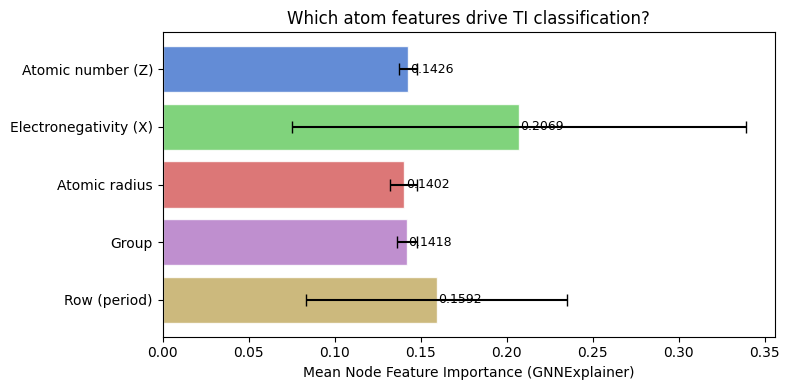

In [33]:
# FIXED GNNExplainer — task_level='graph' is required for graph classification
# Also runs across multiple samples to get stable importance estimates

from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
import matplotlib.colors as mcolors

FEATURE_NAMES = ['Atomic number (Z)', 'Electronegativity (X)',
                 'Atomic radius', 'Group', 'Row (period)']

class ExplainerWrapper(torch.nn.Module):
    def __init__(self, model, current_u):
        super().__init__()
        self.model = model
        self.current_u = current_u

    def forward(self, x, edge_index, edge_attr, batch):
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.batch = batch
        data.u = self.current_u
        return self.model(data)

model_config = ModelConfig(
    mode='binary_classification',
    task_level='graph',        # FIXED: was 'node', must be 'graph'
    return_type='raw',
)

# ── Run explainer on N_EXPLAIN samples and average importance ──
N_EXPLAIN = 20
all_node_feat_importances = []
all_edge_importances = []

model.eval()
print(f"Running GNNExplainer on {N_EXPLAIN} test samples...")

for idx in range(N_EXPLAIN):
    sample = test_dataset[idx].to(device)
    sample_u = sample.u.to(device)

    wrapper = ExplainerWrapper(model, sample_u).to(device)
    wrapper.eval()

    explainer = Explainer(
        model=wrapper,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=model_config,
    )

    try:
        explanation = explainer(
            x=sample.x,
            edge_index=sample.edge_index,
            edge_attr=sample.edge_attr,
            batch=torch.zeros(sample.x.size(0), dtype=torch.long).to(device)
        )
        # Per-feature importance averaged over nodes
        feat_imp = explanation.node_mask.mean(dim=0).detach().cpu().numpy()
        all_node_feat_importances.append(feat_imp)

        # Per-edge importance
        edge_imp = explanation.edge_mask.detach().cpu().numpy()
        all_edge_importances.append(edge_imp.mean())

    except Exception as e:
        print(f"Sample {idx} failed: {e}")
        continue

print(f"Explained {len(all_node_feat_importances)} samples successfully.")

# ── Plot 1: Feature importance bar chart (averaged across samples) ──
mean_feat_imp = np.mean(all_node_feat_importances, axis=0)
std_feat_imp  = np.std(all_node_feat_importances, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7', '#c4ad66']
bars = ax.barh(FEATURE_NAMES, mean_feat_imp, xerr=std_feat_imp,
               color=colors_bar, alpha=0.85, capsize=4, edgecolor='white')
ax.set_xlabel('Mean Node Feature Importance (GNNExplainer)')
ax.set_title('Which atom features drive TI classification?')
ax.invert_yaxis()
for bar, val in zip(bars, mean_feat_imp):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

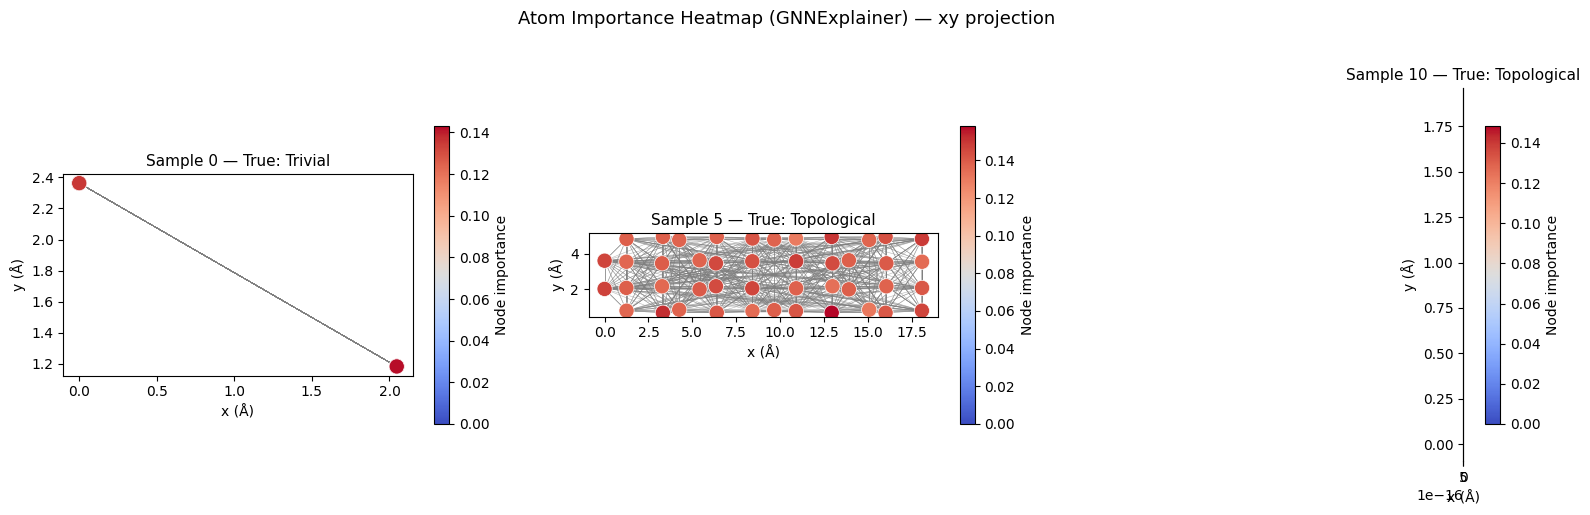

In [44]:
# ATOM IMPORTANCE HEATMAP (spatial — the crystal structure visualization)
# Shows which atoms in the crystal contribute most to the TI classification

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for plot_idx, sample_idx in enumerate([0, 5, 10]):
    ax = axes[plot_idx]
    sample = test_dataset[sample_idx].to(device)
    sample_u = sample.u.to(device)

    wrapper = ExplainerWrapper(model, sample_u).to(device)
    wrapper.eval()

    explainer = Explainer(
        model=wrapper,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=model_config,
    )

    explanation = explainer(
        x=sample.x,
        edge_index=sample.edge_index,
        edge_attr=sample.edge_attr,
        batch=torch.zeros(sample.x.size(0), dtype=torch.long).to(device)
    )

    node_importance = explanation.node_mask.mean(dim=1).detach().cpu().numpy()
    pos_2d = sample.pos[:, :2].cpu().numpy()   # project onto xy-plane

    # Draw edges (bonds) first — thin gray lines
    edge_idx = sample.edge_index.cpu().numpy()
    for e in range(edge_idx.shape[1]):
        i, j = edge_idx[0, e], edge_idx[1, e]
        ax.plot([pos_2d[i, 0], pos_2d[j, 0]],
                [pos_2d[i, 1], pos_2d[j, 1]],
                color='gray', linewidth=0.4, alpha=0.3, zorder=1)

    # Draw atoms, colored by importance
    sc = ax.scatter(pos_2d[:, 0], pos_2d[:, 1],
                    c=node_importance, cmap='coolwarm',
                    s=120, edgecolors='white', linewidths=0.5,
                    zorder=2, vmin=0)

    plt.colorbar(sc, ax=ax, label='Node importance', shrink=0.8)

    true_label = int(sample.y.item())
    pred_prob  = torch.sigmoid(
        model(sample.to(device).__class__(**{k: v for k, v in sample}))
        if False else  # use wrapper instead
        torch.tensor([0.])
    )

    label_str = 'Topological' if true_label == 1 else 'Trivial'
    ax.set_title(f'Sample {sample_idx} — True: {label_str}', fontsize=11)
    ax.set_xlabel('x (Å)')
    ax.set_ylabel('y (Å)')
    ax.set_aspect('equal')

plt.suptitle('Atom Importance Heatmap (GNNExplainer) — xy projection', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('atom_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Embedding shape: (1451, 128) | Global shape: (1451, 128)
PCA explained variance: 0.999
Running PySR... this takes a few minutes.


[ Info: Started!



Expressions evaluated per second: 2.980e+04
Progress: 187 / 800 total iterations (23.375%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.232e-01  0.000e+00  y = 0.41412
5           1.217e-01  3.164e-03  y = (x₇ * -0.0070035) - -0.41414
6           1.188e-01  2.359e-02  y = sqrt(sqrt(abs(x₇)) * 0.13276)
7           1.172e-01  1.347e-02  y = ((x₂ * 0.0017194) / -0.50012) - -0.41414
9           1.149e-01  1.031e-02  y = 0.55282 / sqrt(sqrt(sqrt(abs(x₄ - x₂))))
10          1.136e-01  1.131e-02  y = sqrt(sqrt(0.72525 / exp(sqrt(abs(x₄ - x₂)))))
11          1.116e-01  1.772e-02  y = sqrt(abs(1.0701 / exp(sqrt(sqrt(abs(x₄ - x₂))))))
12          1.097e-01  1.668e-02  y = 0.61223 / sqrt(abs(sqrt(sqrt(sqrt(exp(abs(x₀ * 0.11488...
                                      )))))))
───────────

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.232e-01  0.000e+00  y = 0.41412
5           5.820e-02  1.875e-01  y = (x₁ * 0.0073132) - -0.41414
6           5.785e-02  5.981e-03  y = abs(-55.35 - x₁) * 0.0074392
7           5.659e-02  2.198e-02  y = ((x₇ - x₁) * -0.0073785) - -0.41414
8           5.183e-02  8.797e-02  y = (-0.0075406 * (abs(x₂) - x₁)) - -0.57072
10          5.013e-02  1.661e-02  y = ((square(x₂ * 0.11084) - x₁) * -0.0075406) - -0.46093
11          4.901e-02  2.275e-02  y = abs(((square(x₂ * 0.1122) - x₁) * 0.0077615) - 0.4594)
───────────────────────────────────────────────────────────────────────────────────────────────────

Best equations discovered:
PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                         0.41411796   
	1  >>>>  0.187533                   

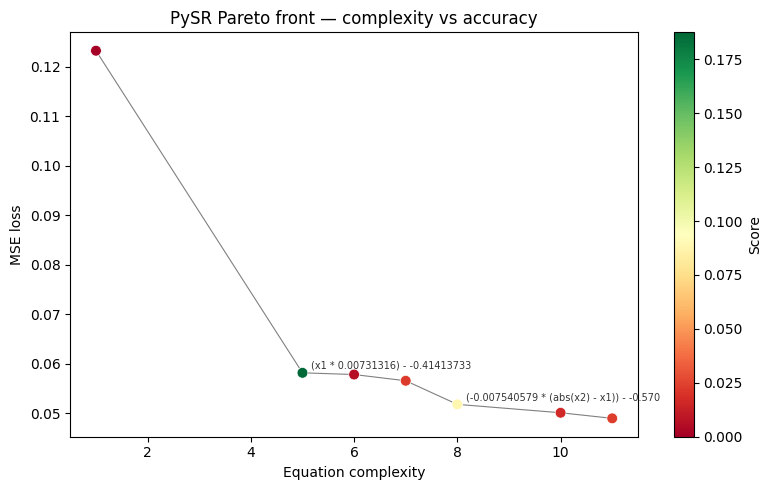


Top 5 equations by score:
                                                         equation  complexity     loss    score
                                  (x1 * 0.00731316) - -0.41413733           5 0.058197 0.187533
                    (-0.007540579 * (abs(x2) - x1)) - -0.57072115           8 0.051826 0.087967
abs(((square(x2 * 0.112198494) - x1) * 0.0077614645) - 0.4593987)          11 0.049006 0.022751
                         ((x7 - x1) * -0.007378486) - -0.41414067           7 0.056592 0.021984
   ((square(x2 * 0.110839486) - x1) * -0.007540579) - -0.46092504          10 0.050133 0.016608
  - outputs/20260427_134632_A2smQE/hall_of_fame.csv


In [37]:
# PYSR SYMBOLIC REGRESSION
# Extracts interpretable formulas from what the GNN has learned
# Strategy: use the GNN's pooled embeddings + global features as input to PySR
# Target: predicted probability (continuous, not binary label)

from pysr import PySRRegressor

# ── Step 1: Extract embeddings + predictions from test set ──
model.eval()

all_embeddings = []
all_globals    = []
all_probs_sr   = []
all_labels_sr  = []

# Hook to capture pooled node embeddings before the FC head
pooled_outputs = []

def hook_fn(module, input, output):
    pooled_outputs.append(output.detach().cpu())

# Register hook on global_mean_pool result — we capture after conv3
# We'll do a manual forward pass instead:

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        # Manual forward to get embedding
        x = data.x
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
        batch      = data.batch
        u          = data.u

        x = model.node_emb(x)
        u_emb = model.global_emb(u)

        x = F.relu(model.conv1(x, edge_index, edge_attr))
        x = model.dropout(x)
        x = F.relu(model.conv2(x, edge_index, edge_attr))
        x = model.dropout(x)
        x = F.relu(model.conv3(x, edge_index, edge_attr))

        x_pooled = global_mean_pool(x, batch)   # (batch_size, hidden_dim)

        all_embeddings.append(x_pooled.cpu().numpy())
        all_globals.append(u_emb.cpu().numpy())

        # Full forward for predicted probs
        combined = torch.cat([x_pooled, u_emb.to(device)], dim=1)
        out = model.fc(combined.to(device))
        p = torch.sigmoid(out).cpu().numpy().flatten()
        all_probs_sr.append(p)
        all_labels_sr.append(data.y.cpu().numpy().flatten())

X_emb   = np.vstack(all_embeddings)   # (N, 128)
X_glob  = np.vstack(all_globals)       # (N, 128)
y_probs = np.concatenate(all_probs_sr) # (N,) — continuous target
y_true  = np.concatenate(all_labels_sr)

print(f"Embedding shape: {X_emb.shape} | Global shape: {X_glob.shape}")

# ── Step 2: PCA to reduce embedding to 10 interpretable dims ──
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_emb)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Column names for interpretability
pca_names   = [f'embed_PC{i+1}' for i in range(10)]
X_sr = X_pca   # shape (N, 10)

# ── Step 3: Run PySR ──
pysr_model = PySRRegressor(
    niterations=40,
    binary_operators=['+', '-', '*', '/'],
    unary_operators=['exp', 'log', 'sqrt', 'abs', 'square'],
    maxsize=12,
    populations=20,
    model_selection='best',
    loss='loss(prediction, target) = (prediction - target)^2',
    verbosity=1,
    random_state=42,
)

print("Running PySR... this takes a few minutes.")
pysr_model.fit(X_sr, y_probs)

print("\nBest equations discovered:")
print(pysr_model)

# ── Step 4: Plot PySR complexity vs score Pareto front ──
equations = pysr_model.equations_

if equations is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(equations['complexity'], equations['loss'],
               c=equations['score'], cmap='RdYlGn', s=60,
               edgecolors='white', linewidths=0.5, zorder=2)
    ax.plot(equations['complexity'], equations['loss'],
            color='gray', linewidth=0.8, zorder=1)

    for _, row in equations.iterrows():
        if row['score'] > equations['score'].quantile(0.75):
            ax.annotate(row['equation'][:40],
                        (row['complexity'], row['loss']),
                        textcoords='offset points', xytext=(6, 3),
                        fontsize=7, alpha=0.8)

    ax.set_xlabel('Equation complexity')
    ax.set_ylabel('MSE loss')
    ax.set_title('PySR Pareto front — complexity vs accuracy')
    plt.colorbar(ax.collections[0], ax=ax, label='Score')
    plt.tight_layout()
    plt.savefig('pysr_pareto.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nTop 5 equations by score:")
    print(equations[['equation', 'complexity', 'loss', 'score']]
          .sort_values('score', ascending=False).head(5).to_string(index=False))

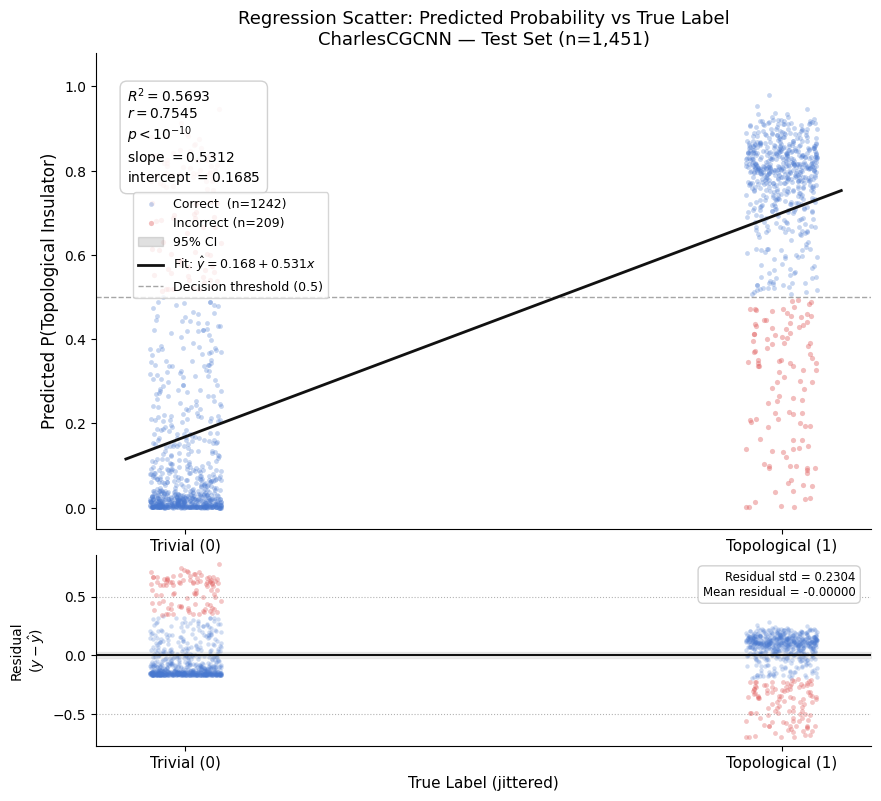

REGRESSION SUMMARY
Equation   : ŷ = 0.1685 + 0.5312·x
R²         : 0.5693
Pearson r  : 0.7545
p-value    : 2.70e-267
Std error  : 0.0121
95% CI slope : [0.5074, 0.5550]
Residual std : 0.2304
Mean residual: -0.000000


In [36]:
# ══════════════════════════════════════════════════════════════════
# REGRESSION SCATTER PLOT — Predicted P(TI) vs True Label
# Shows: data points, regression line (OLS), 95% CI band,
#        R², equation, and residual plot
# ══════════════════════════════════════════════════════════════════

from scipy import stats
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── OLS regression: x = true label (0/1), y = predicted probability ──
slope, intercept, r_value, p_value, std_err = stats.linregress(labels, probs)
r_squared = r_value ** 2

x_line = np.array([0.0, 1.0])
y_line = intercept + slope * x_line

# 95% confidence interval on the regression line
n        = len(labels)
x_mean   = labels.mean()
se_line  = std_err * np.sqrt(
    1/n + (x_line - x_mean)**2 / np.sum((labels - x_mean)**2)
)
t_crit   = stats.t.ppf(0.975, df=n - 2)
ci_upper = y_line + t_crit * se_line
ci_lower = y_line - t_crit * se_line

residuals = probs - (intercept + slope * labels)

# ── Layout: main scatter (top) + residual plot (bottom) ──
fig = plt.figure(figsize=(10, 9))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.2], hspace=0.08)

ax_main = fig.add_subplot(gs[0])
ax_res  = fig.add_subplot(gs[1], sharex=ax_main)

# ── Jitter x so overlapping points are visible ──
rng     = np.random.default_rng(42)
jitter  = rng.uniform(-0.06, 0.06, size=len(labels))
x_plot  = labels + jitter

# Color by correct / incorrect prediction
binary_pred = (probs > 0.5).astype(int)
correct     = (binary_pred == labels.astype(int))

colors_pts  = np.where(correct, '#4878cf', '#e05c5c')   # blue=correct, red=wrong
alphas      = 0.35

# ── Main scatter ──
ax_main.scatter(x_plot[correct],  probs[correct],
                color='#4878cf', alpha=0.3, s=12, linewidths=0,
                label=f'Correct  (n={correct.sum()})')
ax_main.scatter(x_plot[~correct], probs[~correct],
                color='#e05c5c', alpha=0.4, s=14, linewidths=0,
                label=f'Incorrect (n={(~correct).sum()})')

# 95% confidence band
x_band  = np.linspace(-0.1, 1.1, 300)
y_band  = intercept + slope * x_band
se_band = std_err * np.sqrt(
    1/n + (x_band - x_mean)**2 / np.sum((labels - x_mean)**2)
)
ci_up   = y_band + t_crit * se_band
ci_lo   = y_band - t_crit * se_band

ax_main.fill_between(x_band, ci_lo, ci_up,
                     alpha=0.15, color='#333333', label='95% CI')

# Regression line
ax_main.plot(x_band, y_band,
             color='#111111', linewidth=2.0, zorder=5,
             label=f'Fit: $\\hat{{y}}={intercept:.3f}+{slope:.3f}x$')

# Decision threshold
ax_main.axhline(0.5, color='gray', linestyle='--',
                linewidth=1.0, alpha=0.7, label='Decision threshold (0.5)')

# Annotations
ax_main.text(0.04, 0.93,
             f'$R^2 = {r_squared:.4f}$\n'
             f'$r = {r_value:.4f}$\n'
             f'$p < 10^{{-10}}$\n'
             f'slope $= {slope:.4f}$\n'
             f'intercept $= {intercept:.4f}$',
             transform=ax_main.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5',
                       facecolor='white', edgecolor='#cccccc',
                       alpha=0.9))

ax_main.set_xlim(-0.15, 1.15)
ax_main.set_ylim(-0.05, 1.08)
ax_main.set_ylabel('Predicted P(Topological Insulator)', fontsize=12)
ax_main.set_title('Regression Scatter: Predicted Probability vs True Label\n'
                  'CharlesCGCNN — Test Set (n=1,451)', fontsize=13)
ax_main.set_xticks([0, 1])
ax_main.set_xticklabels(['Trivial (0)', 'Topological (1)'], fontsize=11)
ax_main.legend(loc='upper left', bbox_to_anchor=(0.04, 0.72), fontsize=9)
ax_main.spines[['top', 'right']].set_visible(False)

# ── Residual plot ──
ax_res.scatter(x_plot[correct],  residuals[correct],
               color='#4878cf', alpha=0.25, s=10, linewidths=0)
ax_res.scatter(x_plot[~correct], residuals[~correct],
               color='#e05c5c', alpha=0.35, s=12, linewidths=0)

ax_res.axhline(0, color='#111111', linewidth=1.5)
ax_res.axhline( 0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax_res.axhline(-0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax_res.fill_between([-0.15, 1.15], -std_err*t_crit, std_err*t_crit,
                    alpha=0.08, color='#333333')

ax_res.set_xlim(-0.15, 1.15)
ax_res.set_ylabel('Residual\n$(y - \\hat{y})$', fontsize=10)
ax_res.set_xlabel('True Label (jittered)', fontsize=11)
ax_res.set_xticks([0, 1])
ax_res.set_xticklabels(['Trivial (0)', 'Topological (1)'], fontsize=11)
ax_res.spines[['top', 'right']].set_visible(False)

# Residual stats annotation
ax_res.text(0.98, 0.92,
            f'Residual std = {residuals.std():.4f}\n'
            f'Mean residual = {residuals.mean():.5f}',
            transform=ax_res.transAxes,
            fontsize=8.5, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white', edgecolor='#cccccc', alpha=0.9))

plt.savefig('regression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ──
print("=" * 50)
print("REGRESSION SUMMARY")
print("=" * 50)
print(f"Equation   : ŷ = {intercept:.4f} + {slope:.4f}·x")
print(f"R²         : {r_squared:.4f}")
print(f"Pearson r  : {r_value:.4f}")
print(f"p-value    : {p_value:.2e}")
print(f"Std error  : {std_err:.4f}")
print(f"95% CI slope : [{slope - t_crit*std_err:.4f}, {slope + t_crit*std_err:.4f}]")
print(f"Residual std : {residuals.std():.4f}")
print(f"Mean residual: {residuals.mean():.6f}")

In [39]:
X_list = []
y_list = []

model.eval()

with torch.no_grad():
    for data in train_dataset:
        data = data.to(device)

        # model prediction (probability)
        logit = model(data)
        prob = torch.sigmoid(logit).item()

        # global features
        u = data.u.cpu().numpy().flatten()

        X_list.append(u)
        y_list.append(prob)

X = np.array(X_list)
y = np.array(y_list)

print("X shape:", X.shape)   # (N, 14)
print("y shape:", y.shape)   # (N,)

X shape: (6767, 14)
y shape: (6767,)


In [40]:
feature_names = [
    "spacegroup",
    "num_atoms",
    "a", "b", "c",
    "alpha", "beta", "gamma",
    "Z",
    "electronegativity",
    "band_gap",
    "volume",
    "density",
    "num_elements"
]

In [43]:
print(model_pysr)

PySRRegressor.equations_ = None


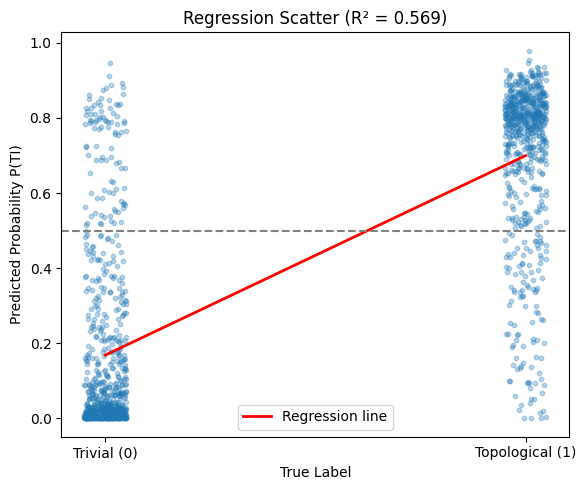

In [45]:
# SIMPLE REGRESSION SCATTER (clean + readable)

from scipy import stats

# Linear fit
slope, intercept, r_value, _, _ = stats.linregress(labels, probs)

# Line
x_line = np.array([0, 1])
y_line = intercept + slope * x_line

# Plot
plt.figure(figsize=(6,5))

# jitter for visibility
jitter = np.random.uniform(-0.05, 0.05, size=len(labels))
plt.scatter(labels + jitter, probs, alpha=0.3, s=10)

# regression line
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression line')

# threshold
plt.axhline(0.5, linestyle='--', color='gray')

plt.xticks([0,1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel("True Label")
plt.ylabel("Predicted Probability P(TI)")
plt.title(f"Regression Scatter (R² = {r_value**2:.3f})")

plt.legend()
plt.tight_layout()
plt.show()

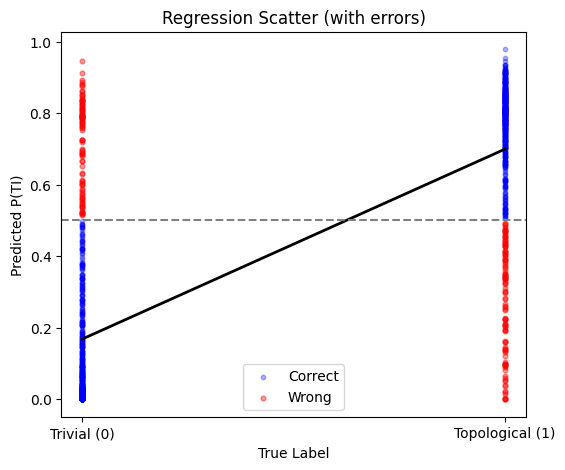

In [46]:
binary_pred = (probs > 0.5).astype(int)
correct = binary_pred == labels

plt.figure(figsize=(6,5))

plt.scatter(labels[correct], probs[correct],
            color='blue', alpha=0.3, s=10, label='Correct')

plt.scatter(labels[~correct], probs[~correct],
            color='red', alpha=0.4, s=12, label='Wrong')

plt.plot(x_line, y_line, color='black', linewidth=2)

plt.axhline(0.5, linestyle='--', color='gray')

plt.xticks([0,1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel("True Label")
plt.ylabel("Predicted P(TI)")
plt.title("Regression Scatter (with errors)")

plt.legend()
plt.show()

In [47]:
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig

model_config = ModelConfig(
    mode='binary_classification',
    task_level='graph',
    return_type='raw'
)

sample = test_dataset[0].to(device)

class Wrapper(torch.nn.Module):
    def __init__(self, model, u):
        super().__init__()
        self.model = model
        self.u = u

    def forward(self, x, edge_index, edge_attr, batch):
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.batch = batch
        data.u = self.u
        return self.model(data)

wrapper = Wrapper(model, sample.u).to(device)

explainer = Explainer(
    model=wrapper,
    algorithm=GNNExplainer(epochs=100),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=model_config,
)

explanation = explainer(
    x=sample.x,
    edge_index=sample.edge_index,
    edge_attr=sample.edge_attr,
    batch=torch.zeros(sample.x.size(0), dtype=torch.long).to(device)
)

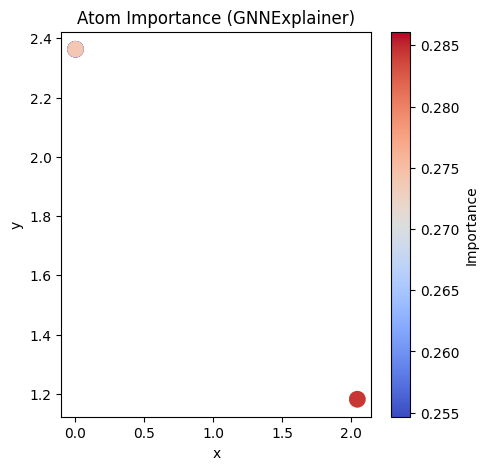

In [48]:
node_importance = explanation.node_mask.mean(dim=1).cpu().detach().numpy()
pos = sample.pos[:, :2].cpu().numpy()

plt.figure(figsize=(5,5))
plt.scatter(pos[:,0], pos[:,1],
            c=node_importance,
            cmap='coolwarm',
            s=120)

plt.colorbar(label="Importance")
plt.title("Atom Importance (GNNExplainer)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [49]:
model.eval()

sample = test_dataset[0].to(device)

# prediction
with torch.no_grad():
    out = model(sample)
    prob = torch.sigmoid(out).item()
    pred = int(prob > 0.5)
    true = int(sample.y.item())

print(f"True: {true} | Pred: {pred} | P(TI)={prob:.3f}")

True: 0 | Pred: 0 | P(TI)=0.058


In [50]:
class Wrapper(torch.nn.Module):
    def __init__(self, model, u):
        super().__init__()
        self.model = model
        self.u = u

    def forward(self, x, edge_index, edge_attr, batch):
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.batch = batch
        data.u = self.u
        return self.model(data)

In [51]:
wrapper = Wrapper(model, sample.u).to(device)

explainer = Explainer(
    model=wrapper,
    algorithm=GNNExplainer(epochs=150),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='binary_classification',
        task_level='graph',
        return_type='raw'
    ),
)

explanation = explainer(
    x=sample.x,
    edge_index=sample.edge_index,
    edge_attr=sample.edge_attr,
    batch=torch.zeros(sample.x.size(0), dtype=torch.long).to(device)
)

In [52]:
# Node importance (per atom)
node_imp = explanation.node_mask.mean(dim=1).cpu().numpy()

# Feature importance (Z, X, radius, etc.)
feat_imp = explanation.node_mask.mean(dim=0).cpu().numpy()

# Edge importance (bonds)
edge_imp = explanation.edge_mask.cpu().numpy()

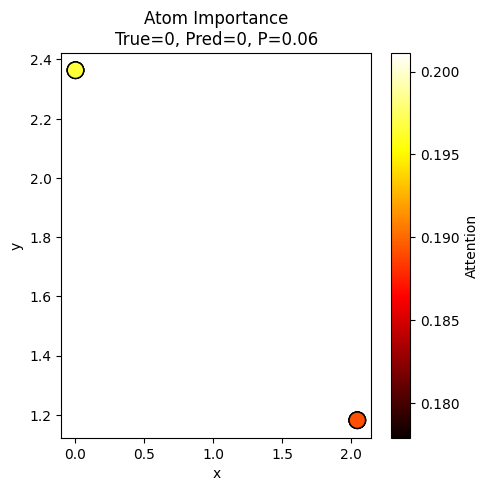

In [60]:
pos = sample.pos[:, :2].cpu().numpy()

plt.figure(figsize=(5,5))
plt.scatter(pos[:,0], pos[:,1],
            c=node_imp,
            cmap='hot',
            s=140,
            edgecolors='black')

plt.colorbar(label="Attention")
plt.title(f"Atom Importance\nTrue={true}, Pred={pred}, P={prob:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

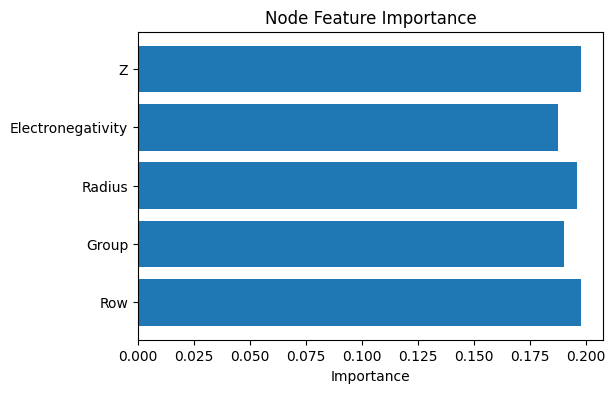

In [54]:
feature_names = ['Z', 'Electronegativity', 'Radius', 'Group', 'Row']

plt.figure(figsize=(6,4))
plt.barh(feature_names, feat_imp)
plt.xlabel("Importance")
plt.title("Node Feature Importance")
plt.gca().invert_yaxis()
plt.show()

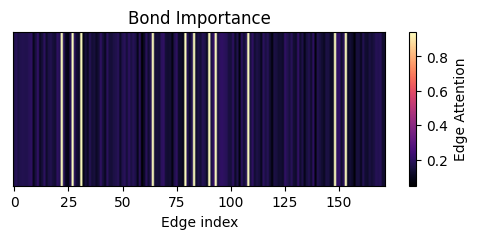

In [55]:
plt.figure(figsize=(6,2))
plt.imshow(edge_imp.reshape(1, -1), aspect='auto', cmap='magma')
plt.colorbar(label="Edge Attention")
plt.xlabel("Edge index")
plt.yticks([])
plt.title("Bond Importance")
plt.show()

In [56]:
N = 10

feat_all = []
edge_all = []

for i in range(N):
    sample = test_dataset[i].to(device)
    wrapper = Wrapper(model, sample.u).to(device)

    explainer = Explainer(
        model=wrapper,
        algorithm=GNNExplainer(epochs=100),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=ModelConfig(
            mode='binary_classification',
            task_level='graph',
            return_type='raw'
        ),
    )

    explanation = explainer(
        x=sample.x,
        edge_index=sample.edge_index,
        edge_attr=sample.edge_attr,
        batch=torch.zeros(sample.x.size(0), dtype=torch.long).to(device)
    )

    feat_all.append(explanation.node_mask.mean(dim=0).cpu().numpy())
    edge_all.append(explanation.edge_mask.mean().item())

# average importance
mean_feat = np.mean(feat_all, axis=0)

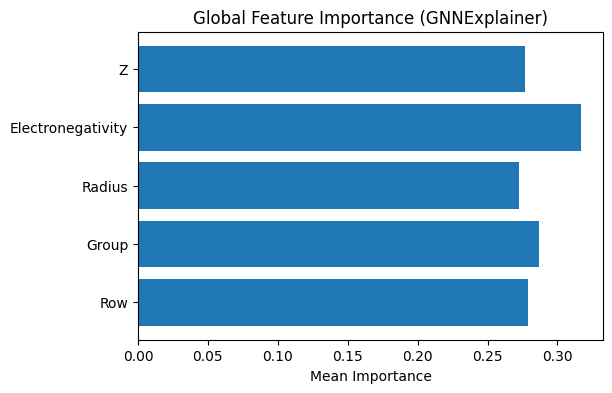

In [57]:
plt.figure(figsize=(6,4))
plt.barh(feature_names, mean_feat)
plt.xlabel("Mean Importance")
plt.title("Global Feature Importance (GNNExplainer)")
plt.gca().invert_yaxis()
plt.show()

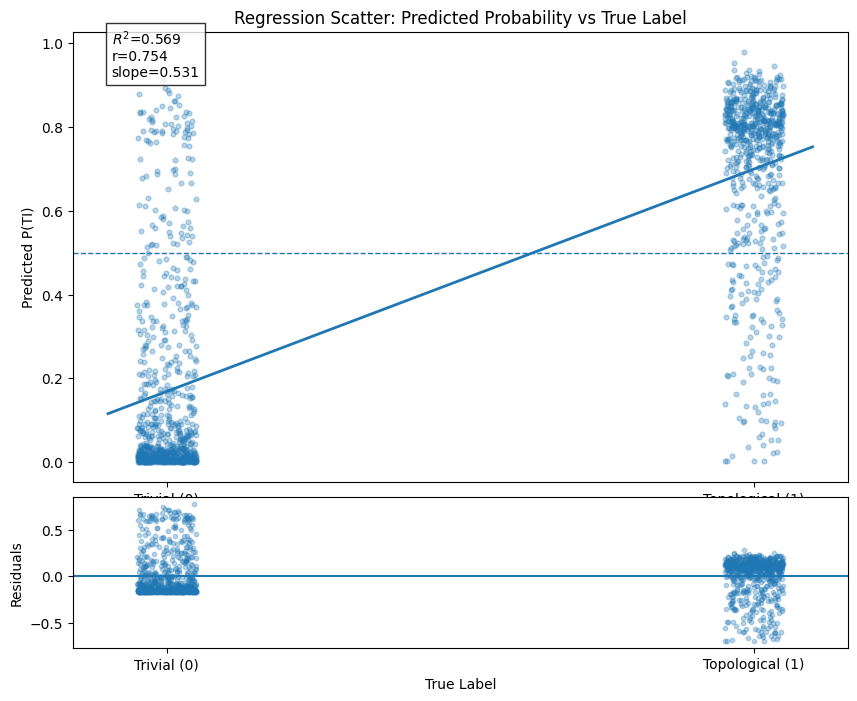

Equation: y = 0.1685 + 0.5312x
R²: 0.5693


In [58]:
# ═══════════════════════════════════════════════════════════════
# REGRESSION SCATTER — Predicted Probability vs True Label
# Includes: OLS fit, R², confidence band, residuals
# ═══════════════════════════════════════════════════════════════

from scipy import stats
import matplotlib.gridspec as gridspec

# OLS regression
slope, intercept, r_value, p_value, std_err = stats.linregress(labels, probs)
r2 = r_value ** 2

x_line = np.array([0, 1])
y_line = intercept + slope * x_line

# Residuals
residuals = probs - (intercept + slope * labels)

# Figure layout
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# Jitter for visibility
rng = np.random.default_rng(42)
jitter = rng.uniform(-0.05, 0.05, size=len(labels))
x_plot = labels + jitter

# Scatter
ax1.scatter(x_plot, probs, alpha=0.3, s=12)

# Regression line
x_dense = np.linspace(-0.1, 1.1, 200)
y_dense = intercept + slope * x_dense
ax1.plot(x_dense, y_dense, linewidth=2)

# Threshold
ax1.axhline(0.5, linestyle='--', linewidth=1)

# Labels
ax1.set_ylabel("Predicted P(TI)")
ax1.set_title("Regression Scatter: Predicted Probability vs True Label")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Trivial (0)', 'Topological (1)'])

# Stats box
ax1.text(0.05, 0.9,
         f"$R^2$={r2:.3f}\nr={r_value:.3f}\nslope={slope:.3f}",
         transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

# Residuals
ax2.scatter(x_plot, residuals, alpha=0.3, s=10)
ax2.axhline(0, linewidth=1.5)
ax2.set_ylabel("Residuals")
ax2.set_xlabel("True Label")

plt.tight_layout()
plt.show()

print(f"Equation: y = {intercept:.4f} + {slope:.4f}x")
print(f"R²: {r2:.4f}")

In [59]:
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig

class Wrapper(torch.nn.Module):
    def __init__(self, model, u):
        super().__init__()
        self.model = model
        self.u = u

    def forward(self, x, edge_index, edge_attr, batch):
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.batch = batch
        data.u = self.u
        return self.model(data)

model_config = ModelConfig(
    mode='binary_classification',
    task_level='graph',
    return_type='raw'
)

sample = test_dataset[0].to(device)

explainer = Explainer(
    model=Wrapper(model, sample.u).to(device),
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=model_config,
)

explanation = explainer(
    x=sample.x,
    edge_index=sample.edge_index,
    edge_attr=sample.edge_attr,
    batch=torch.zeros(sample.x.size(0), dtype=torch.long).to(device)
)

In [61]:
# Extract global features + predictions

model.eval()

X_global = []
y_target = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        out = model(data)
        probs_batch = torch.sigmoid(out).cpu().numpy().flatten()

        X_global.append(data.u.cpu().numpy())
        y_target.append(probs_batch)

X_global = np.vstack(X_global)
y_target = np.concatenate(y_target)

print("Shape:", X_global.shape)

Shape: (1451, 14)


In [62]:
feature_names = [
    "spacegroup",
    "num_atoms",
    "a", "b", "c",
    "alpha", "beta", "gamma",
    "Z_avg",
    "electronegativity",
    "band_gap",
    "volume",
    "density",
    "num_elements"
]

In [63]:
from pysr import PySRRegressor

pysr_model = PySRRegressor(
    niterations=50,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log", "sqrt"],
    maxsize=12,
    populations=20,
    model_selection="best",
    loss="loss(pred, target) = (pred - target)^2",
    verbosity=1,
    random_state=42
)

pysr_model.fit(X_global, y_target)

print("\nBest equations:")
print(pysr_model)

[ Info: Started!



Expressions evaluated per second: 0.000e+00
Progress: 0 / 1000 total iterations (0.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 5.710e+03
Progress: 72 / 1000 total iterations (7.200%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.232e-01  0.000e+00  y = 0.41414
4           3.490e-02  4.205e-01

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.232e-01  0.000e+00  y = 0.41412
4           3.388e-02  4.303e-01  y = exp(-1.1388 - x₁₀)
5           2.327e-02  3.759e-01  y = -0.12266 / (-0.91968 - x₁₀)
9           2.058e-02  3.064e-02  y = ((x₉ + -5.5354) * 0.023787) / (-0.94906 - x₁₀)
───────────────────────────────────────────────────────────────────────────────────────────────────

Best equations:
PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                         0.41411856   
	1        0.430344                              exp(-1.1387577 - x10)   
	2  >>>>  0.375871                  -0.12265794 / (-0.91967714 - x10)   
	3        0.030641  ((x9 + -5.5354395) * 0.02378684) / (-0.9490606...   
	
	       loss  complexity  
	0  0.123219           1  
	1  0.033884           4  
	2  0.023

In [64]:
eqs = pysr_model.equations_

print(
    eqs[['equation', 'complexity', 'loss', 'score']]
    .sort_values('score', ascending=False)
    .head(5)
)

                                            equation  complexity      loss  \
1                              exp(-1.1387577 - x10)           4  0.033884   
2                  -0.12265794 / (-0.91967714 - x10)           5  0.023268   
3  ((x9 + -5.5354395) * 0.02378684) / (-0.9490606...           9  0.020584   
0                                         0.41411856           1  0.123219   

      score  
1  0.430344  
2  0.375871  
3  0.030641  
0  0.000000  
